# Eksperyment: Wpływ funkcji aktywacji na wyniki MLP

W tym notatniku zbadamy wpływ funkcji aktywacji (`sigmoid`, `gelu`, `identity`) na proces uczenia modelu MLP. Notatnik jest skonfigurowany do obsługi zarówno zadań **klasyfikacji** (np. XOR), jak i **regresji** (np. dopasowanie do funkcji). 

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp import MLP
from mlp.utils import (
    plot_loss, plot_weight_evolution, plot_decision_boundary, 
    train_test_split, accuracy, mse, plot_predictions, load_dataset
)

# Konfiguracja
SEED = 44
np.random.seed(SEED)

# === KONFIGURACJA EKSPERYMENTU ===
# Odkomentuj jeden z bloków, aby wybrać zadanie

# --- BLOK 1: Klasyfikacja (Oryginalny problem XOR) ---
# TASK = "binary"
TASK = "binary"
CSV_PATH = "../lab1_data/Classification/data.noisyXOR.train.1000.csv"
# `load_dataset` automatycznie znormalizuje {1, 2} -> {0, 1}
# LAYER_SIZES = [2, 32, 2] # Wejście 2D (x, y), Wyjście 2 (dla 2 klas)
LAYER_SIZES = [2, 32, 1] # Wejście 2D (x, y), Wyjście 2 (dla 2 klas)

# --- BLOK 2: Regresja (Przykład) ---
TASK = "regression"
CSV_PATH = "../lab1_data/Regression/data.multimodal.train.1000.csv" 
LAYER_SIZES = [1, 32, 1] # Wejście 1D (x), Wyjście 1D (y)


config = {
    "epochs": 10000,
    "learning_rate": 0.001,
}

activations = ["sigmoid", "gelu", "identity"]

## Wczytanie i wizualizacja danych

[load_dataset] Detected REGRESSION: normalized target (mean=-200.130, std=98.717)
Wczytano X: (1000, 1), y: (1000, 1)
Unikalne etykiety y: [-1.79891151 -1.79669879 -1.79617704 -1.79579466 -1.79037392 -1.78914321
 -1.78516183 -1.78124409 -1.77592597 -1.77358026 -1.77305804 -1.77230981
 -1.76956669 -1.76608993 -1.76596797 -1.76313413 -1.76146273 -1.76017603
 -1.75485513 -1.75283104 -1.74793615 -1.74023123 -1.73596837 -1.72847173
 -1.72769161 -1.72690986 -1.71050887 -1.69994471 -1.69473437 -1.69128503
 -1.6765333  -1.65209468 -1.65058085 -1.64020828 -1.63858728 -1.60858593
 -1.60563303 -1.59010347 -1.58060245 -1.56764657 -1.55469396 -1.55393532
 -1.55238692 -1.5515786  -1.54381339 -1.54234057 -1.51517053 -1.51440947
 -1.51077453 -1.50949428 -1.48362051 -1.48218021 -1.48180358 -1.47476002
 -1.47446501 -1.44372401 -1.44335654 -1.43450894 -1.4247549  -1.41875769
 -1.40968319 -1.40140618 -1.40077321 -1.3992891  -1.39803211 -1.37856957
 -1.36230851 -1.3601452  -1.35504631 -1.33435015 -1.332334

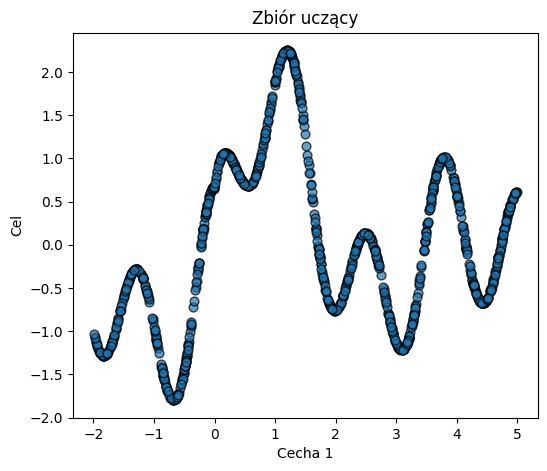

In [46]:
# Użycie nowej funkcji load_dataset
X, y = load_dataset(CSV_PATH)

# Metoda .fit() dla regresji i klasyfikacji binarnej oczekuje y (m, 1)
# a load_dataset() zwraca (m,). Dostosowujemy kształt.
if TASK == "regression" or TASK == "binary":
    y = y.reshape(-1, 1)

print(f"Wczytano X: {X.shape}, y: {y.shape}")
print(f"Unikalne etykiety y: {np.unique(y)}")

plt.figure(figsize=(6, 5))

if X.shape[1] == 2:
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="tab10", s=40, edgecolors="k")
    plt.xlabel("Cecha 1")
    plt.ylabel("Cecha 2")
elif X.shape[1] == 1:
    plt.scatter(X[:, 0], y.ravel(), s=40, edgecolors="k", alpha=0.7)
    plt.xlabel("Cecha 1")
    plt.ylabel("Cel")
            
plt.title("Zbiór uczący")
plt.show()

## Trening modeli dla różnych funkcji aktywacji

In [47]:
# UWAGA: pomijamy standaryzację (X-mean)/std.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=SEED)

print(f"Całkowity zbiór: {len(X)} próbek")
print(f"Zbiór treningowy: {len(X_train)} próbek")
print(f"Zbiór testowy: {len(X_test)} próbek")

results = {}

for act in activations:
    print(f"\n=== Trening dla aktywacji: {act} (Zadanie: {TASK}) ===")
    model = MLP(
        layer_sizes=LAYER_SIZES, 
        task=TASK,               
        activation=act,
        learning_rate=config["learning_rate"],
        seed=SEED,
    )

    losses, weight_hist, accuracy_history = model.fit(X_train, y_train, epochs=config["epochs"], verbose=False)

    preds = model.predict(X_test)
    
    # Obliczenie straty na zbiorze testowym
    if TASK == "multiclass":
        y_test_ohe = model._to_one_hot_encoding(y_test, LAYER_SIZES[-1])
        loss_test = model.compute_loss(X_test, y_test_ohe)
    else:
        loss_test = model.compute_loss(X_test, y_test)

    # Obliczanie metryki
    if TASK == "regression":
        metric = mse(y_test, preds)
        metric_name = "MSE (TEST)"
    else:
        metric = accuracy(y_test, preds)
        metric_name = "Dokładność (TEST)"

    results[act] = {
        "model": model,
        "losses": losses,       
        "weights": weight_hist, 
        "loss_test": loss_test,   # Strata testowa
        "metric": metric,       # Metryka testowa (Acc lub MSE)
        "metric_name": metric_name
    }


    print(f"Końcowa strata (trening): {losses[-1]:.6f} | {metric_name}: {metric:.4f} | Strata (TEST): {loss_test:.6f}")

Całkowity zbiór: 1000 próbek
Zbiór treningowy: 700 próbek
Zbiór testowy: 300 próbek

=== Trening dla aktywacji: sigmoid (Zadanie: regression) ===
Końcowa strata (trening): 0.633254 | MSE (TEST): 0.6230 | Strata (TEST): 0.623008

=== Trening dla aktywacji: gelu (Zadanie: regression) ===
Końcowa strata (trening): 0.486754 | MSE (TEST): 0.4731 | Strata (TEST): 0.473063

=== Trening dla aktywacji: identity (Zadanie: regression) ===
Końcowa strata (trening): 0.966855 | MSE (TEST): 1.0045 | Strata (TEST): 1.004499


## Wizualizacja wyników


### Funkcja aktywacji: sigmoid


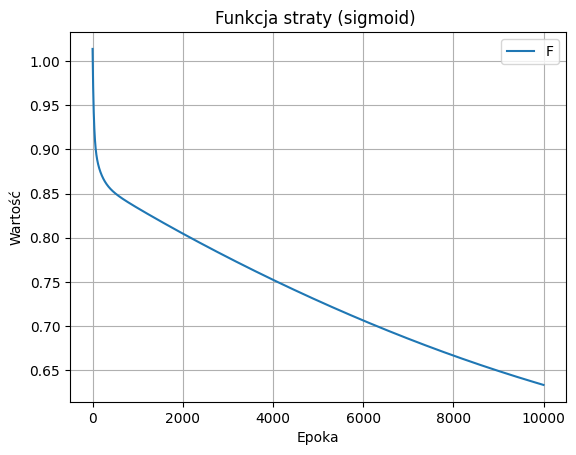

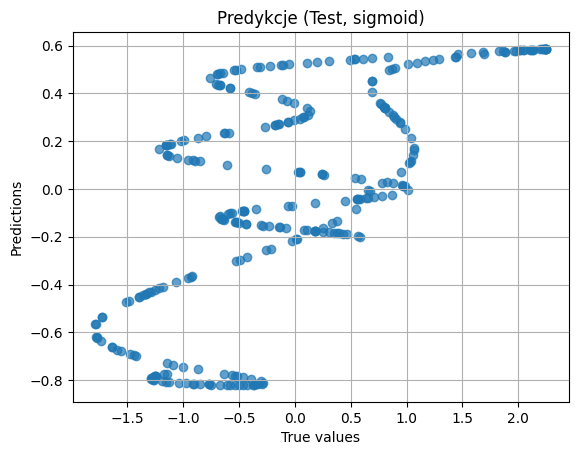

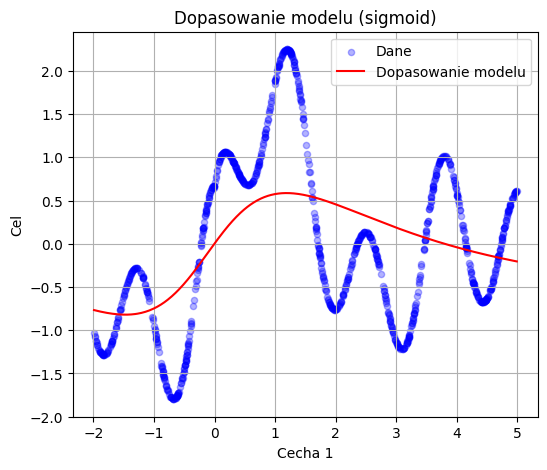

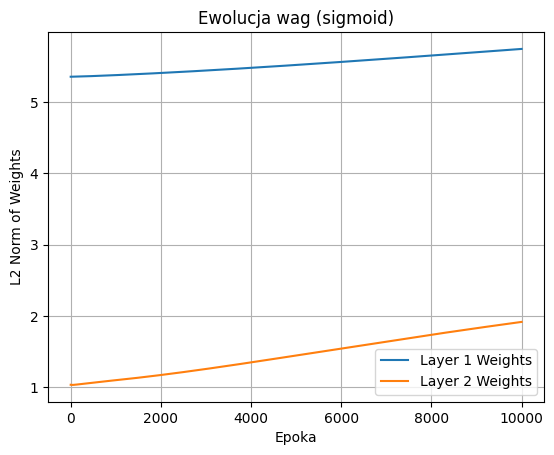


### Funkcja aktywacji: gelu


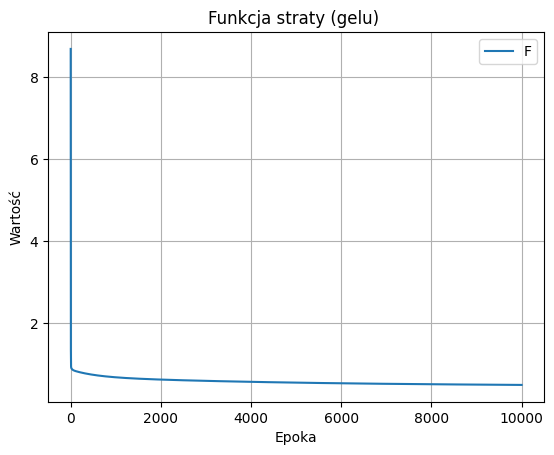

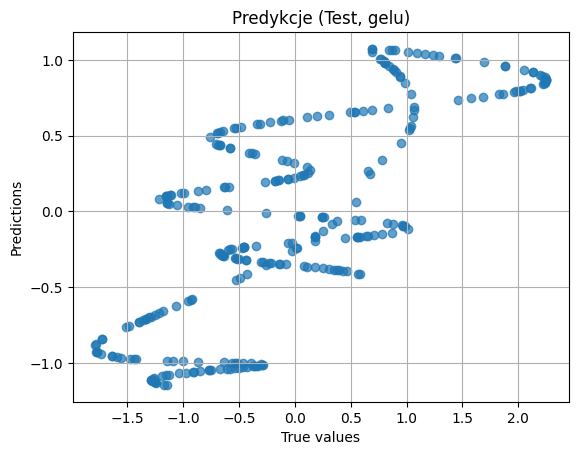

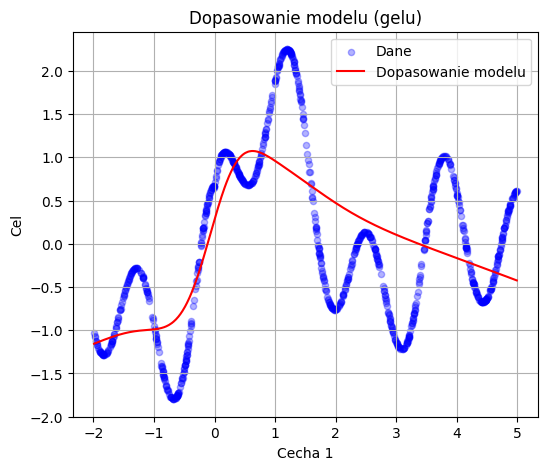

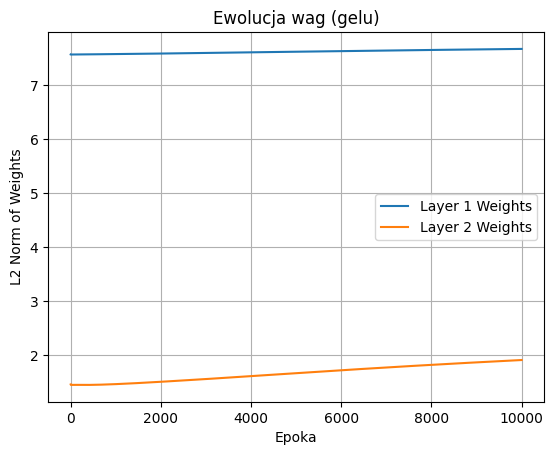


### Funkcja aktywacji: identity


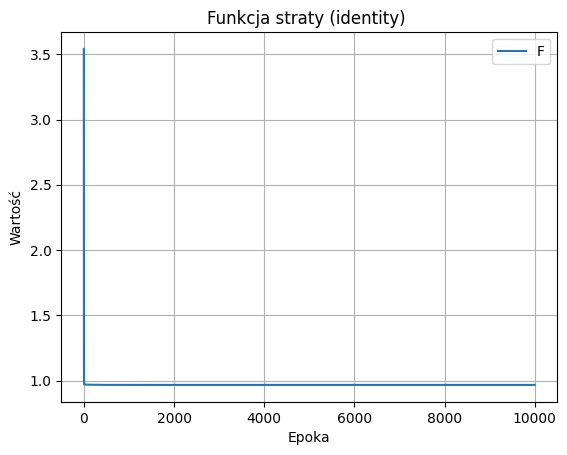

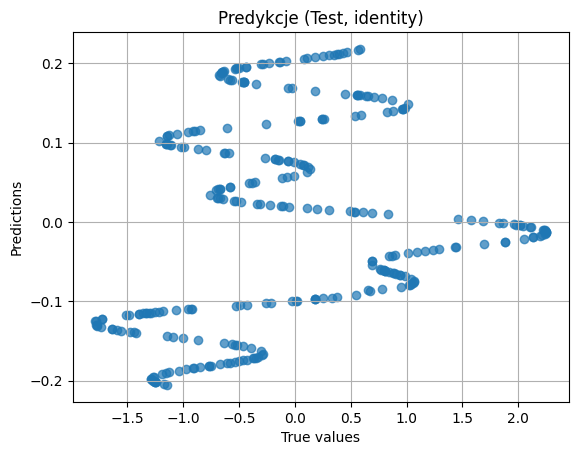

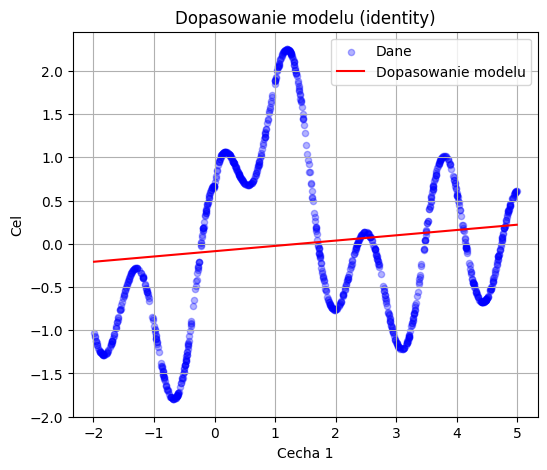

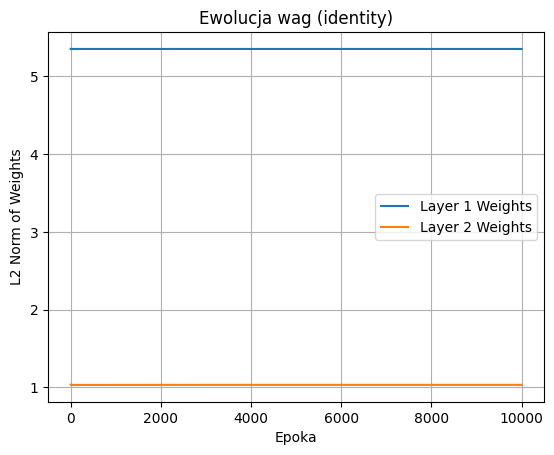

In [48]:
for act, data in results.items():
    print(f"\n### Funkcja aktywacji: {act}")
    
    # 1. Wykres straty (wspólny)
    title = f"Funkcja straty ({act}) "
    plot_loss(data["losses"], title=title)
    
    # 2. Wykres specyficzny dla zadania (Granica decyzyjna / Predykcje)
    task_type = data["model"].task
    
    if task_type == "regression":
        if X.shape[1] == 1:
            # Dla regresji 1D, pokaż predykcje vs rzeczywiste na zbiorze testowym
            preds_test = data["model"].predict(X_test)
            plot_predictions(y_test, preds_test, title=f"Predykcje (Test, {act})")
            
            # Pokaż dopasowanie modelu do całego zbioru X
            plt.figure(figsize=(6, 5))
            plt.scatter(X, y, color="blue", label="Dane", alpha=0.3, s=20)
            # Sortowanie X dla ładnego wykresu linii
            X_sorted_idx = np.argsort(X.ravel())
            X_sorted = X[X_sorted_idx]
            preds_all_sorted = data["model"].predict(X_sorted)
            plt.plot(X_sorted, preds_all_sorted, color="red", label="Dopasowanie modelu")
            plt.title(f"Dopasowanie modelu ({act})")
            plt.xlabel("Cecha 1")
            plt.ylabel("Cel")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print(f"Wizualizacja regresji obsługiwana tylko dla 1 cechy wejściowej (X). Pomięto wykres predykcji dla {act}.")
    
    else: # "binary" or "multiclass"
        if X.shape[1] == 2:
            # Dla klasyfikacji 2D, pokaż granicę decyzyjną (na danych testowych)
            plot_decision_boundary(data["model"], X_test, y_test, title=f"Granica decyzyjna ({act})")
        else:
            print(f"Wizualizacja granicy decyzyjnej obsługiwana tylko dla 2 cech wejściowych (X). Pomięto wykres dla {act}.")
    
    # 3. Wykres ewolucji wag (wspólny)
    plot_weight_evolution(data["weights"], title=f"Ewolucja wag ({act})")

## Podsumowanie

Eksperymenty zmieniając `LAYER_SIZES`, `epochs`, `learning_rate` oraz przełączając `TASK`.